# S09: Context Radius Expansion

This talktorial asks how much local neighbourhood should be kept around a reaction center. We expand reaction-center templates by radius, apply the resulting rule libraries, and use recall, enrichment, and F1 to choose a practical context size [\[1\]](#6.-References), [\[2\]](#6.-References), [\[3\]](#6.-References).


## Aim of this talktorial

1. Define the **r-hop context** around a reaction center on an ITS graph.
2. Implement transparent BFS-based context expansion and build deduplicated template libraries for several radii.
3. Evaluate the recall-enrichment trade-off and choose a practical radius from validation evidence.

---

## Learning outcomes

After completing this talktorial, you will be able to:

- define the *r*-hop context neighbourhood $N_r(C)$ on an ITS graph,
- explain how context controls the generality-specificity trade-off of a DPO rule,
- implement BFS-based context expansion,
- build deduplicated template libraries at several radii,
- evaluate forward prediction with recall@K and enrichment@K, and
- choose a practical context radius using evidence rather than guesswork.

---

## Outline

- [0. Setup & data](#0.-Setup-&-data)
- [1. What is context?](#1.-What-is-context?)
- [2. Template radius deep-dive — radii 0–5](#2.-Template-radius-deep-dive-—-radii-0–5)
- [3. Choosing a radius in practice](#3.-Choosing-a-radius-in-practice)
- [4. Discussion](#4.-Discussion)
- [5. Quiz](#5.-Quiz)
- [6. References](#6.-References)


## 0. Setup & data

In [23]:
%matplotlib inline
import rdkit
import pandas as pd
import networkx as nx
from pathlib import Path
import importlib.metadata as _m
from synkit.IO import load_database
import logging


def _silence():
    logging.disable(logging.CRITICAL)


_silence()

print("RDKit    :", rdkit.__version__)
print("NetworkX :", nx.__version__)
print("SynKit   :", _m.version('synkit'))

DATA_PATH = Path("data") / "smart.json.gz"
data = pd.DataFrame(load_database(DATA_PATH)[:2000])
print(f"\nDataset : {data.shape[0]} reactions  ·  columns: {list(data.columns)}")
data.head(3)

RDKit    : 2025.09.3
NetworkX : 3.6.1
SynKit   : 1.3.2

Dataset : 2000 reactions  ·  columns: ['R-id', 'smart']


,R-id,smart
0,7873,[CH3:1][C:2]([CH3:3])([CH3:4])[O:5][C:6](=[O:7...
1,42468,[Br:1][CH2:2][c:3]1[cH:4][cH:6][c:7]([Br:8])[c...
2,24541,[CH3:1][N:2]([CH3:3])[CH2:4][CH2:5][NH:6][H:7]...


**Split the dataset**

We use an 80 / 20 train / test split with the same seed as S08 so that results
are comparable. The training split is used to build template libraries at every
radius; the test split is reserved for evaluation.

In [24]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)
print(f"Train : {len(train_df)}  |  Test : {len(test_df)}")

Train : 1600  |  Test : 400


**Build the rule library — ITS, WL hash, and clustering**

We reuse the exact pipeline from S07/S08:

1. Convert each training reaction to its full ITS graph and to its
   reaction-center (RC) graph.
2. Compute a WL hash of each RC for fast grouping.
3. Cluster with `GraphCluster` to identify rule families.

This is shown quickly here; refer to S07 for a step-by-step explanation.

In [25]:
from synkit.IO import rsmi_to_its
from synkit.Graph.Feature.wl_hash import WLHash
from synkit.Graph.Matcher.graph_cluster import GraphCluster
from synkit.Chem.Reaction.standardize import Standardize

_wl = WLHash()
train = train_df.to_dict("records")
for v in train:
    v["ITS"] = rsmi_to_its(v["smart"], core=False)  # full ITS (all atoms)
    v["RC"] = rsmi_to_its(v["smart"], core=True)  # reaction-center only
    v["wl"] = _wl.weisfeiler_lehman_graph_hash(v["RC"])

_cls = GraphCluster()
cluster = _cls.fit(train, rule_key="RC", attribute_key="wl")

_df_cls = pd.DataFrame(cluster)
print("Rule family sizes (top 8):")
print(_df_cls["class"].value_counts().head(8).to_string())

Rule family sizes (top 8):
class
6     281
0     208
4     111
17    105
5      80
9      75
12     62
2      57


**Standardize the test set**

We remove atom mapping from test reactions so that the predictor never sees the
ground-truth correspondence. Standardization also normalizes ring perception and
aromaticity, which is required for fair chemical comparison.

In [41]:
_std = Standardize()
test = test_df.to_dict("records")
for v in test:
    _rsmi = _std.fit(v["smart"], remove_aam=True)
    v["r"], v["p"] = _rsmi.split(">>")
    v["rsmi"] = _rsmi
    v["ITS"] = rsmi_to_its(v["smart"], core=False)
    v["RC"] = rsmi_to_its(v["smart"], core=True)
    v["wl"] = _wl.weisfeiler_lehman_graph_hash(v["RC"])

print(
    f"Test set standardised and assigned to reaction-center families: {len(test)} entries"
)
print("Example — reactant :", test[0]["r"][:60], "...")

Test set standardised and assigned to reaction-center families: 400 entries
Example — reactant : Brc1ccc(OCC2Cn3c(nc4ccccc43)O2)cc1.Cn1nccc1B1OC(C)(C)C(C)(C) ...


## 1. What is context?

The *reaction center* captures the minimum subgraph that changes in a reaction.
**Context expansion** augments that minimal representation by pulling in the
chemical neighbourhood around it.  Here, we
build the expansion by hand so the mechanism is fully transparent.

### 1.1 Recap reaction center

From **S04**: an edge (u, v) in the ITS graph belongs to the **reaction center**
$E_{rc}$ if its bond orders on the reactant and product sides differ:

$$E_{\text{rc}} = \{(u,v) \in E \mid b_r(u,v) \neq b_p(u,v)\}$$

The **reaction-center nodes** $V_{rc}$ are all endpoints of edges in $E_{rc}$ [\[1\]](#6.-References), [\[3\]](#6.-References).
At radius *r* = 0, $V_{rc}$ is the starting seed for context expansion.

In [27]:
def reaction_center_nodes(its: nx.Graph) -> set:
    """Return atoms incident to any bond that changes between reactant and product."""
    rc = set()
    for u, v, d in its.edges(data=True):
        br, bp = d.get("order", (0.0, 0.0))
        if abs(float(br) - float(bp)) > 1e-6:
            rc.update([u, v])
    return rc


# Quick check on the first training reaction
_its_ex = cluster[0]["ITS"]
_rc_ex = reaction_center_nodes(_its_ex)
print(
    f"ITS has {_its_ex.number_of_nodes()} nodes, " f"{_its_ex.number_of_edges()} edges"
)
print(f"Reaction-center nodes: {sorted(_rc_ex)}")

ITS has 35 nodes, 41 edges
Reaction-center nodes: [15, 16, 33, 34]


### 1.2 Defining the r-hop context

**Definition.** Let  $C \subseteq V$  be the reaction-center atoms of an ITS graph G.
The *r-hop context* is:

$$
N_r(C) = \left\{ v \in V \mid \operatorname{dist}(v, C) \leq r \right\},
$$
where

$$
\operatorname{dist}(v, C) = \min_{c \in C} d_G(v, c)
$$

is the shortest-path distance in G.

The **context subgraph** $K_r$ is the subgraph of G induced by $N_r(C)$.

| r | What is included |
|---|---|
| 0 | Only the atoms that directly break or form bonds |
| 1 | Those atoms + all their immediate ITS neighbours |
| 2 | r=1 context + one more shell of neighbours |
| k | All atoms within k hops of any reaction-center atom |

At r = 0, $K_r$ is the smallest possible rule (maximum generality).
Each additional hop adds chemical context, increasing specificity.

### 1.3 Implement `expand_context` from scratch

**Q1.** Before reading the solution below, try to implement `expand_context(its, r)`
yourself: given an ITS graph and a radius *r*, return the induced subgraph of all nodes
within *r* hops of the reaction center.

*Hint*: start with a frontier set equal to the reaction-center nodes.
Each iteration, extend the frontier by one shell of neighbours and merge into
the accumulated set.

In [44]:
def expand_context(its: nx.Graph, r: int) -> nx.Graph:
    """Return the ITS subgraph within r hops of the reaction center."""
    seed = reaction_center_nodes(its)
    frontier = set(seed)
    for _ in range(r):
        next_shell = set()
        for v in frontier:
            next_shell.update(its.neighbors(v))
        frontier = next_shell - seed  # only brand-new nodes
        seed |= frontier
    return its.subgraph(seed).copy()


# Verify: r=0 should give back exactly the reaction-center subgraph
_ctx0 = expand_context(_its_ex, 0)
_ctx1 = expand_context(_its_ex, 1)
_ctx2 = expand_context(_its_ex, 2)
print(f"r=0 → {_ctx0.number_of_nodes()} nodes")
print(f"r=1 → {_ctx1.number_of_nodes()} nodes")
print(f"r=2 → {_ctx2.number_of_nodes()} nodes")
print(f"Full ITS → {_its_ex.number_of_nodes()} nodes")

r=0 → 4 nodes
r=1 → 7 nodes
r=2 → 10 nodes
Full ITS → 35 nodes


### 1.4 Visualise r = 0, 1, 2 on one ITS

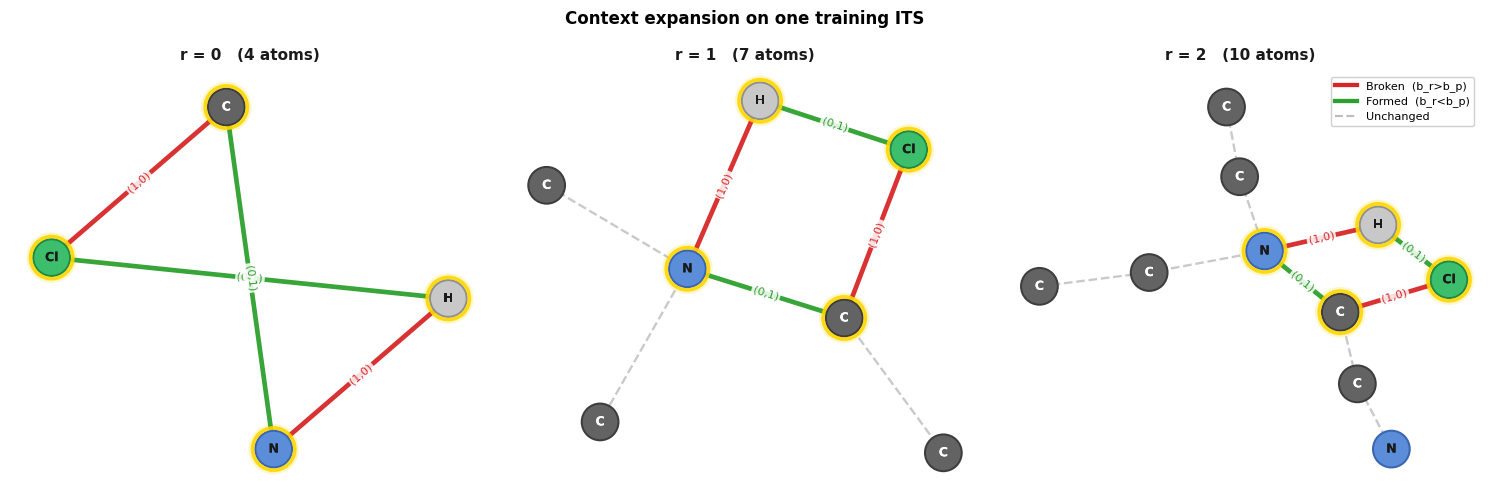

Gold rings mark reaction-center atoms (changed bonds).
Each +1 radius adds one shell of chemical neighbours.


In [45]:
import matplotlib.pyplot as plt
from synedu.Utils.its_vis import visualize_its

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor="white")
fig.suptitle("Context expansion on one training ITS", fontsize=12, fontweight="bold")

for k, ax in enumerate(axes):
    ctx = expand_context(_its_ex, k)
    visualize_its(
        ctx,
        ax=ax,
        title=f"r = {k}   ({ctx.number_of_nodes()} atoms)",
        show_legend=(k == 2),
        show_edge_labels=True,
    )

plt.tight_layout()
plt.show()
print("Gold rings mark reaction-center atoms (changed bonds).")
print("Each +1 radius adds one shell of chemical neighbours.")

### 1.5 The context subgraph as local DPO rule support

In S05 we defined a **DPO span** L ← K → R where K is the *interface*
subgraph — the part of the rule that is not rewritten.

The context subgraph $K_r$ built above supplies the local atoms and ITS edge labels from which the DPO span is read:

- **L** = the reactant-side view of $K_r$ (with $b_r$ bond orders)
- **R** = the product-side view of $K_r$ (with $b_p$ bond orders)
- **K** = the shared atom interface; unchanged bonds are preserved in $K$, while broken, formed, or order-changed bonds appear in $L$ and/or $R$ according to their side-specific labels

A larger $K_r$ carries more chemical context. The rule therefore pattern-matches fewer
substrates and usually generates a more focused candidate list. In evaluation, this often
appears as a trade-off: recall@K may decrease, while enrichment can improve because fewer
irrelevant candidates need to be inspected.


## 2. Template radius deep-dive — radii 0–5

We now use the context expansion function from Section 1 to build template libraries at
several radii. To keep the lesson simple, we study one representative rule family rather
than comparing many families at once.


### 2.1 Pick one rule family

Working family: class 6
Training reactions in this family: 281
Test reactions in the same reaction-center family: 65


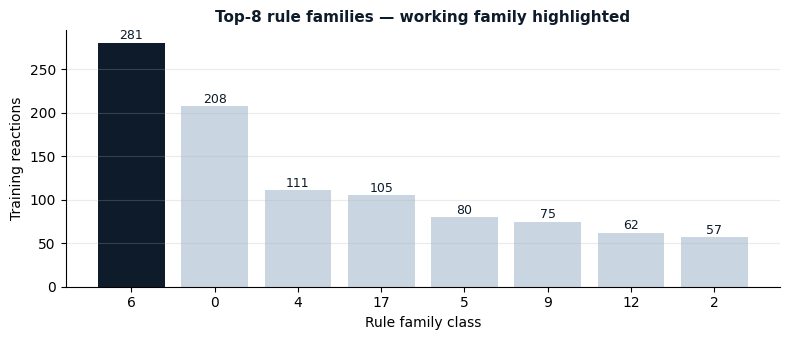

In [30]:
TOP_CLASS = int(_df_cls["class"].value_counts().idxmax())
family_train = [v for v in cluster if v["class"] == TOP_CLASS]
_family_wl = family_train[0]["wl"]
family_test = [v for v in test if v["wl"] == _family_wl]

if not family_test:
    raise ValueError("No test reactions share the selected reaction-center family.")

print(f"Working family: class {TOP_CLASS}")
print(f"Training reactions in this family: {len(family_train)}")
print(f"Test reactions in the same reaction-center family: {len(family_test)}")

# Show the 8 most common rule families as a bar chart.
import matplotlib.pyplot as plt

_vc = _df_cls["class"].value_counts().head(8)
fig, ax = plt.subplots(figsize=(8, 3.5), facecolor="white")
bars = ax.bar(
    _vc.index.astype(str),
    _vc.values,
    color=["#0E1B2A" if c == TOP_CLASS else "#C9D6E2" for c in _vc.index],
)
ax.set_xlabel("Rule family class", fontsize=10)
ax.set_ylabel("Training reactions", fontsize=10)
ax.set_title(
    "Top-8 rule families — working family highlighted",
    fontsize=11,
    fontweight="bold",
    color="#0E1B2A",
)
for bar, val in zip(bars, _vc.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.5,
        str(val),
        ha="center",
        va="bottom",
        fontsize=9,
        color="#0E1B2A",
    )
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Let us look at a few representative reactions from this family to confirm
they share the same reaction-center topology.

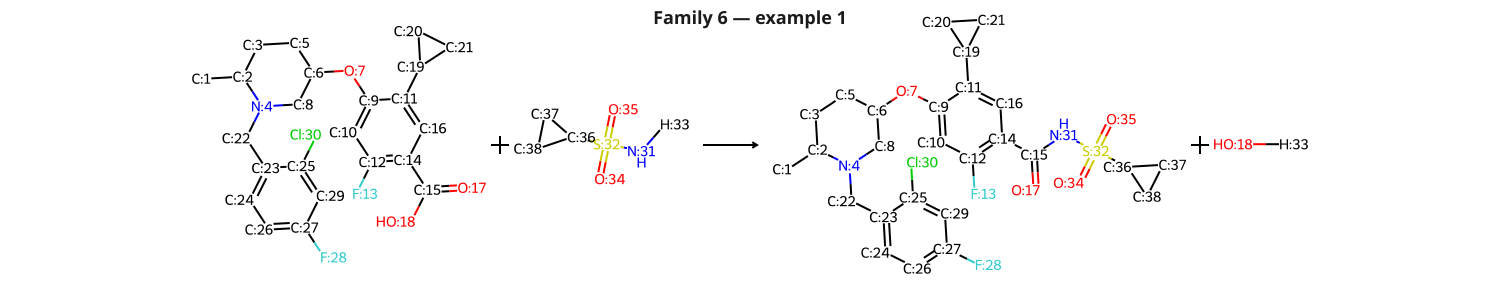

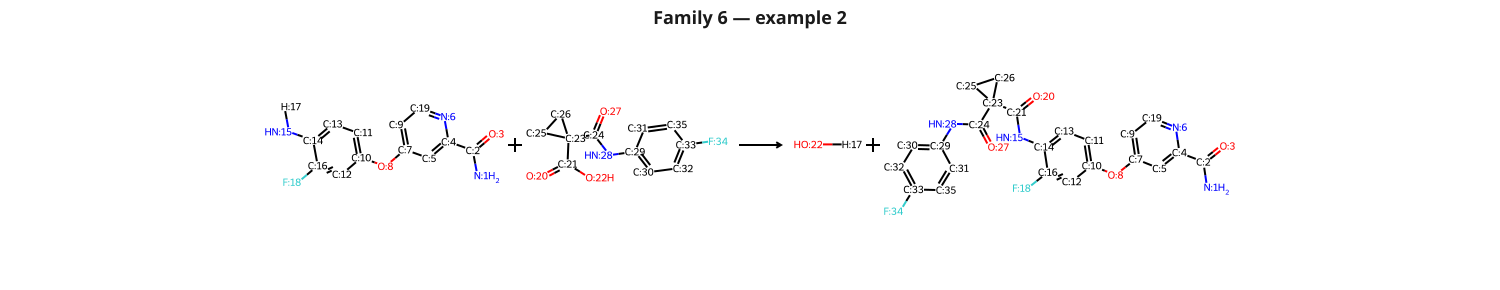

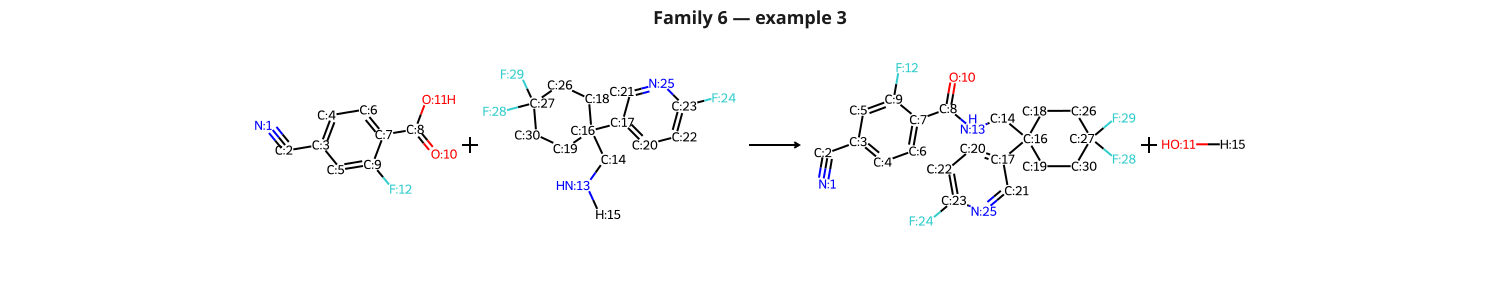

In [31]:
from synedu.Utils.rxn_vis import visualize_reaction
from IPython.display import SVG, display

_samples = family_train[:3]
for i, v in enumerate(_samples):
    display(
        SVG(
            visualize_reaction(
                v["smart"],
                svg=True,
                legend=f"Family {TOP_CLASS} — example {i+1}",
                highlight_changes=True,
            )
        )
    )

### 2.2 Build templates at each radius

For each training reaction in the selected family, we extract the r-hop context subgraph [\[4\]](#6.-References)
with `expand_context(its, r)`. We then deduplicate the resulting K-graphs with a WL hash.

The result is a plain list:

```python
_templates[r] = [
    {"K": context_graph, "hash": wl_hash, "source_idx": training_index},
    ...
]
```

This is intentionally simple: no extra hierarchy, just one template set per radius.


In [32]:
MAX_RADIUS = 5


def make_radius_templates(records, max_radius=MAX_RADIUS):
    """Build deduplicated r-hop context templates for one reaction family."""
    templates = []
    for r in range(max_radius + 1):
        seen = set()
        level = []
        for idx, record in enumerate(records):
            K = expand_context(record["ITS"], r)
            h = _wl.weisfeiler_lehman_graph_hash(K)
            if h in seen:
                continue
            seen.add(h)
            level.append({"K": K, "hash": h, "source_idx": idx})
        templates.append(level)
    return templates


_templates = make_radius_templates(family_train, max_radius=MAX_RADIUS)

for r, tlist in enumerate(_templates):
    print(f"r = {r}: {len(tlist):3d} unique templates")

r = 0:   1 unique templates
r = 1:  30 unique templates
r = 2: 156 unique templates
r = 3: 261 unique templates
r = 4: 274 unique templates
r = 5: 278 unique templates


### 2.3 Template count vs. radius

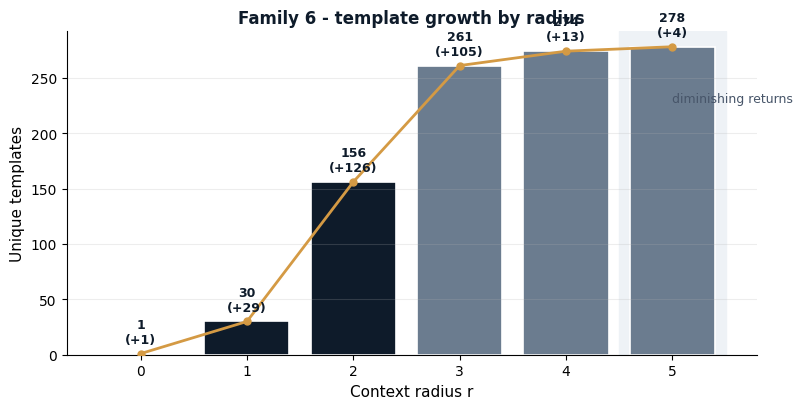


Key observation:
 r=0 -> 1 template   (all reactions share the same reaction center)
 r=1 -> many more    (immediate neighbourhood already differentiates reactions)
 r>=3 -> near-plateau (family is nearly fully disambiguated)


In [33]:
import matplotlib.pyplot as plt
import numpy as np

_radii = np.array(range(len(_templates)))
_counts = np.array([len(tl) for tl in _templates])
_delta = np.diff(_counts, prepend=0)
fig, ax = plt.subplots(figsize=(8.2, 4.2), facecolor="white")
bar_colors = ["#0E1B2A" if r <= 2 else "#6B7C8F" for r in _radii]
bars = ax.bar(_radii, _counts, color=bar_colors, edgecolor="white", linewidth=1.2)
ax.plot(_radii, _counts, color="#D49A44", lw=2.0, marker="o", ms=5, zorder=3)
for bar, cnt, d in zip(bars, _counts, _delta):
    label = f"{cnt}\n(+{d})" if d > 0 else f"{cnt}"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        cnt + max(_counts.max() * 0.025, 0.8),
        label,
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#0E1B2A",
    )
if len(_counts) > 2:
    small_gain = np.where(_delta <= max(1, _counts.max() * 0.03))[0]
    plateau_r = int(small_gain[1]) if len(small_gain) > 1 else int(_radii[-1])
    ax.axvspan(plateau_r - 0.5, _radii[-1] + 0.5, color="#EEF2F6", zorder=0)
    ax.text(
        plateau_r,
        _counts.max() * 0.82,
        "diminishing returns",
        fontsize=9,
        color="#475569",
    )
ax.set_xlabel("Context radius r", fontsize=11)
ax.set_ylabel("Unique templates", fontsize=11)
ax.set_title(
    f"Family {TOP_CLASS} - template growth by radius",
    fontsize=12,
    fontweight="bold",
    color="#0E1B2A",
)
ax.set_xticks(_radii)
ax.grid(axis="y", alpha=0.22)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
print("\nKey observation:")
print(" r=0 -> 1 template   (all reactions share the same reaction center)")
print(" r=1 -> many more    (immediate neighbourhood already differentiates reactions)")
print(" r>=3 -> near-plateau (family is nearly fully disambiguated)")

We draw one representative K-graph per radius using `visualize_its`
(which handles ITS-style edge attributes automatically).

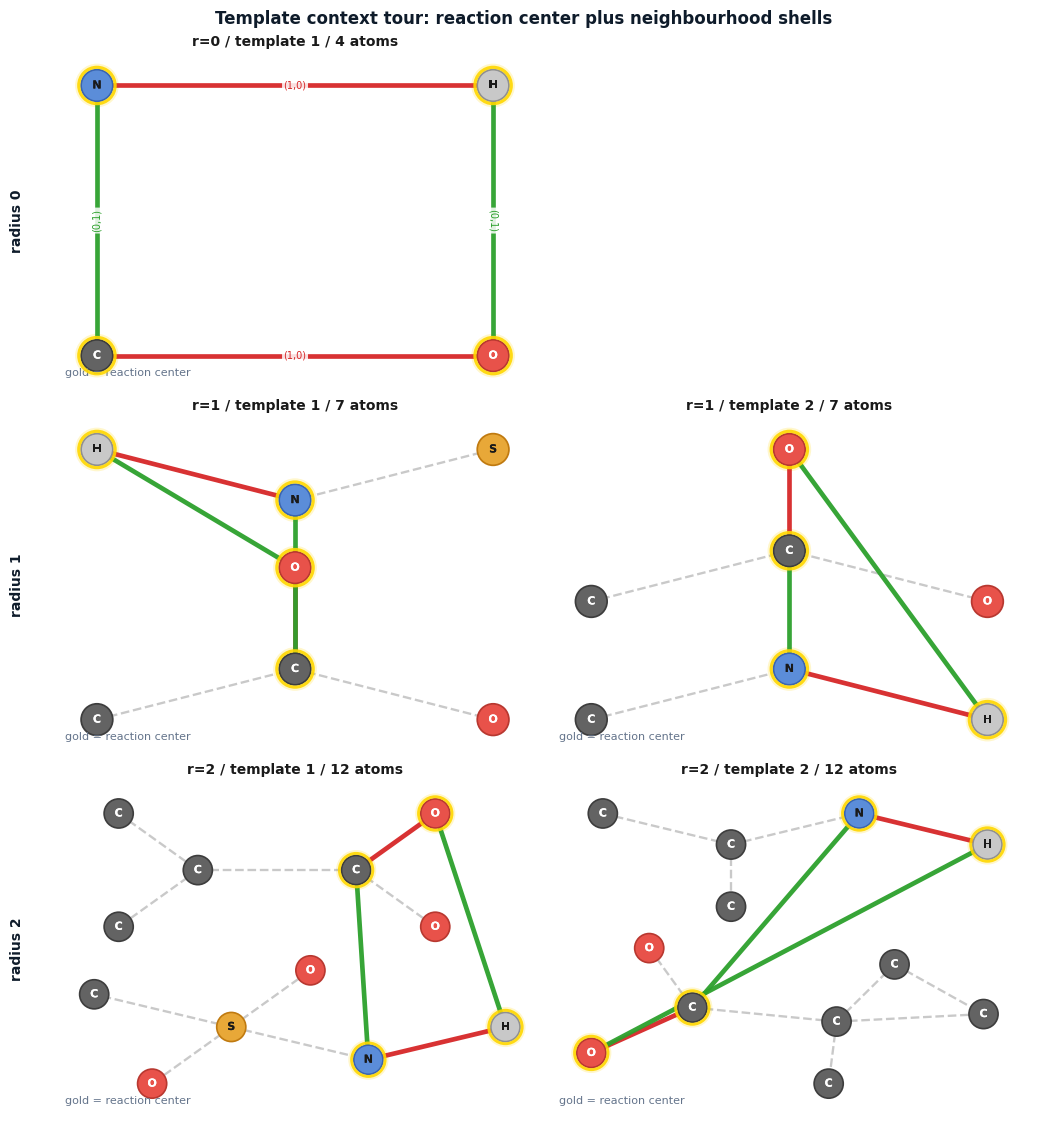

In [34]:
import matplotlib.pyplot as plt
from synedu.Utils.its_vis import visualize_its

_show_radii = [0, 1, 2]
_n_show = 2
fig, axes = plt.subplots(
    len(_show_radii),
    _n_show,
    figsize=(_n_show * 5.2, len(_show_radii) * 3.8),
    facecolor="white",
)
fig.suptitle(
    "Template context tour: reaction center plus neighbourhood shells",
    fontsize=12,
    fontweight="bold",
    color="#0E1B2A",
)
for row, r in enumerate(_show_radii):
    row_templates = _templates[r]
    for col in range(_n_show):
        ax = axes[row][col]
        if col < len(row_templates):
            K = row_templates[col]["K"]
            visualize_its(
                K,
                ax=ax,
                coordinate="reactant",
                title=f"r={r} / template {col + 1} / {K.number_of_nodes()} atoms",
                show_legend=False,
                show_edge_labels=(r == 0),
                node_size=520 if r < 2 else 440,
                font_size=8,
            )
            ax.text(
                0.02,
                0.02,
                "gold = reaction center",
                transform=ax.transAxes,
                fontsize=8,
                color="#64748B",
                ha="left",
                va="bottom",
            )
        else:
            ax.set_axis_off()
    axes[row][0].text(
        -0.08,
        0.5,
        f"radius {r}",
        transform=axes[row][0].transAxes,
        rotation=90,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#0E1B2A",
    )
plt.tight_layout()
plt.show()

### 2.4 Evaluate each radius

We now apply each radius's template library to test reactions from the **same reaction-center family**. This keeps the comparison local: each radius is trying to solve the same class of chemistry, rather than being averaged across unrelated rule classes.

| Metric | What it captures |
|---|---|
| **Recall@K** | Fraction of same-family test reactions where the standardized ground truth appears in the first K unique candidates |
| **Enrichment@K** | Mean hit density inside the first K unique candidates; with one ground truth this is `hit / n_candidates` |
| **F1@K** | Harmonic mean of recall@K and enrichment@K, used here as the radius trade-off score |

We use `SynReactor` for generation, then standardize and deduplicate predictions before computing recall@K, enrichment@K, and F1@K. In this section, K is fixed to 50 so the radius comparison stays easy to read.


In [ ]:
from synkit.Synthesis.Reactor.syn_reactor import SynReactor

_std2 = Standardize()


def _unique_preserve_order(values):
    seen = set()
    out = []
    for value in values:
        if value in seen:
            continue
        seen.add(value)
        out.append(value)
    return out


def _apply_templates(entries, template_graphs, *, n_entries=25):
    """Apply a list of K-graph templates to up to n_entries test reactions."""
    subset = entries[:n_entries]
    for v in subset:
        fw = []
        for K in template_graphs:
            try:
                reactor = SynReactor(
                    substrate=v["r"],
                    template=K,
                    explicit_h=True,
                    implicit_temp=False,
                    automorphism=True,
                )
                fw.extend(reactor.smarts_list)
            except Exception:
                pass
        clean = []
        for s in fw:
            try:
                c = _std2.fit(s)
                if c:
                    clean.append(c)
            except Exception:
                pass
        v["fw_clean"] = _unique_preserve_order(clean)
    return subset


def f1_tradeoff(recall, enrichment):
    """Harmonic mean between recall and enrichment."""
    if recall + enrichment == 0:
        return 0.0
    return 2 * recall * enrichment / (recall + enrichment)


def recall_enrichment_at_k(entries, *, key_gt="rsmi", key_pred="fw_clean", k=50):
    """Compute standardized recall/enrichment using top-k or all candidates."""
    recalls = []
    enrichments = []

    for entry in entries:
        gt = entry.get(key_gt)
        all_preds = entry.get(key_pred, [])
        preds = all_preds if k is None else all_preds[:k]
        hit = int(gt in preds)
        recalls.append(hit)
        enrichments.append(hit / len(preds) if preds else 0.0)

    if not entries:
        return {"recall_at_k": 0.0, "enrichment_at_k": 0.0}

    return {
        "recall_at_k": sum(recalls) / len(recalls),
        "enrichment_at_k": sum(enrichments) / len(enrichments),
    }


print("Evaluation helpers ready.")

Evaluation helpers ready.


In [36]:
import copy
import time

_eval_results = []
_N_TEST = 25  # same-family test entries used per radius (keep notebook fast)
_EVAL_K = 50
_eval_source = family_test[:_N_TEST]

print(f"Evaluating {len(_eval_source)} test reactions from class {TOP_CLASS}.")

for r, tlist in enumerate(_templates):
    t0 = time.time()
    tmpl_graphs = [t["K"] for t in tlist]

    # Work on fresh copies so we do not accumulate fw_clean across iterations.
    _entries = copy.deepcopy(_eval_source)
    _entries = _apply_templates(_entries, tmpl_graphs, n_entries=len(_entries))

    elapsed = time.time() - t0
    m = recall_enrichment_at_k(_entries, k=_EVAL_K)
    score = f1_tradeoff(m["recall_at_k"], m["enrichment_at_k"])

    _eval_results.append(
        {
            "r": r,
            "n_templates": len(tlist),
            "elapsed": round(elapsed, 2),
            f"Recall@{_EVAL_K}": round(m["recall_at_k"], 3),
            f"Enrichment@{_EVAL_K}": round(m["enrichment_at_k"], 4),
            f"F1@{_EVAL_K}": round(score, 4),
            "tradeoff_score": round(score, 4),
        }
    )
    print(
        f"r={r}  templates={len(tlist):3d}  "
        f"Recall@{_EVAL_K}={_eval_results[-1][f'Recall@{_EVAL_K}']:.3f}  "
        f"Enrichment@{_EVAL_K}={_eval_results[-1][f'Enrichment@{_EVAL_K}']:.4f}  "
        f"F1@{_EVAL_K}={_eval_results[-1][f'F1@{_EVAL_K}']:.4f}  "
        f"({elapsed:.1f}s)"
    )

_eval_df = pd.DataFrame(_eval_results)
print("\nDone.")

Evaluating 25 test reactions from class 6.
r=0  templates=  1  Recall@50=1.000  Enrichment@50=0.4311  F1@50=0.6024  (0.4s)
r=1  templates= 30  Recall@50=0.960  Enrichment@50=0.5558  F1@50=0.7040  (4.1s)
r=2  templates=156  Recall@50=0.840  Enrichment@50=0.5717  F1@50=0.6803  (13.8s)
r=3  templates=261  Recall@50=0.640  Enrichment@50=0.4400  F1@50=0.5215  (23.6s)
r=4  templates=274  Recall@50=0.480  Enrichment@50=0.4000  F1@50=0.4364  (27.1s)
r=5  templates=278  Recall@50=0.320  Enrichment@50=0.3000  F1@50=0.3097  (25.7s)

Done.


### 2.5 Trade-off curve

The two-panel figure below is the central diagnostic of S09:

- **Left panel** — Recall@K, enrichment@K, and their F1 score as radius increases.
  This shows whether larger context is helping both recovery and focus.
- **Right panel** — Recall@K versus enrichment@K, one point per radius.
  Moving right means the answer appears more often; moving up means the candidate list is more focused when the answer appears.

The highlighted radius maximizes `tradeoff_score`, defined here as the harmonic mean of recall@K and enrichment@K. This is not a universal objective; it is a compact visual guide for comparing radii inside one reaction-center family.


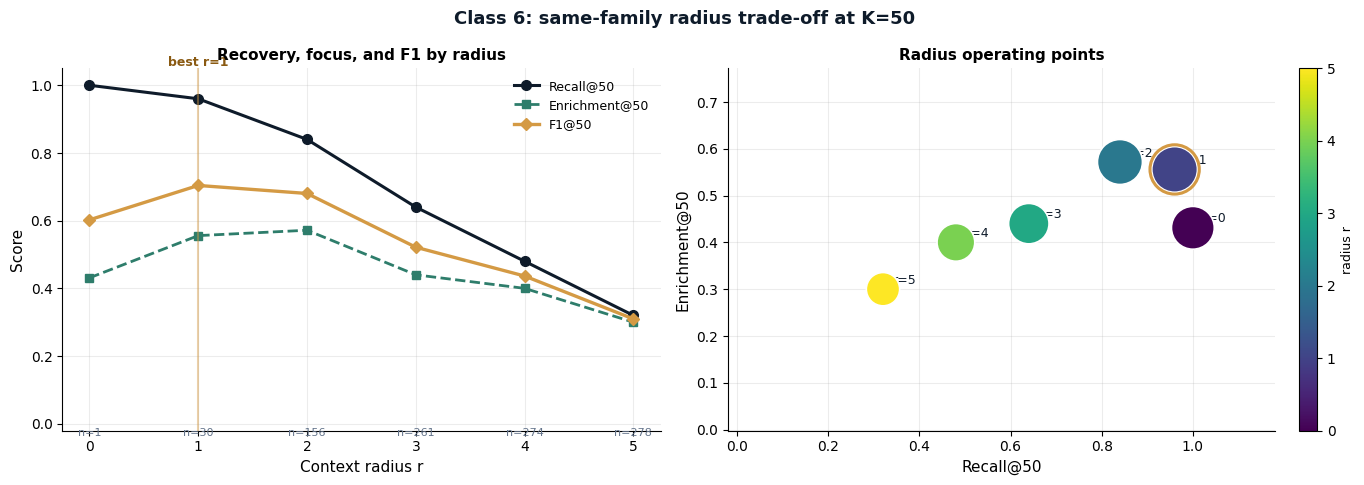

 r  n_templates  Recall@50  Enrichment@50  F1@50  tradeoff_score  elapsed
 0            1       1.00         0.4311 0.6024          0.6024     0.39
 1           30       0.96         0.5558 0.7040          0.7040     4.07
 2          156       0.84         0.5717 0.6803          0.6803    13.85
 3          261       0.64         0.4400 0.5215          0.5215    23.56
 4          274       0.48         0.4000 0.4364          0.4364    27.07
 5          278       0.32         0.3000 0.3097          0.3097    25.72


In [37]:
import matplotlib.pyplot as plt
import numpy as np

_recall_col = f"Recall@{_EVAL_K}"
_enrich_col = f"Enrichment@{_EVAL_K}"
_f1_col = f"F1@{_EVAL_K}"
_best = _eval_df.loc[_eval_df["tradeoff_score"].idxmax()]
_r = _eval_df["r"].to_numpy()

fig, (ax_curve, ax_scatter) = plt.subplots(1, 2, figsize=(13.8, 4.9), facecolor="white")
fig.suptitle(
    f"Class {TOP_CLASS}: same-family radius trade-off at K={_EVAL_K}",
    fontsize=13,
    fontweight="bold",
    color="#0E1B2A",
)

ax_curve.plot(
    _eval_df["r"],
    _eval_df[_recall_col],
    "o-",
    color="#0E1B2A",
    lw=2.2,
    ms=7,
    label=_recall_col,
)
ax_curve.plot(
    _eval_df["r"],
    _eval_df[_enrich_col],
    "s--",
    color="#2E7D6B",
    lw=2.0,
    ms=6,
    label=_enrich_col,
)
ax_curve.plot(
    _eval_df["r"], _eval_df[_f1_col], "D-", color="#D49A44", lw=2.4, ms=6, label=_f1_col
)
ax_curve.axvline(int(_best["r"]), color="#D49A44", lw=1.5, alpha=0.45)
ax_curve.text(
    int(_best["r"]),
    max(_eval_df[[_recall_col, _enrich_col, _f1_col]].max()) * 1.05,
    f"best r={int(_best['r'])}",
    ha="center",
    va="bottom",
    fontsize=9,
    color="#8A5A12",
    fontweight="bold",
)
for _, row in _eval_df.iterrows():
    ax_curve.text(
        row["r"],
        -0.012,
        f"n={int(row['n_templates'])}",
        ha="center",
        va="top",
        fontsize=8,
        color="#64748B",
        clip_on=False,
    )
ax_curve.set_xlabel("Context radius r", fontsize=11)
ax_curve.set_ylabel("Score", fontsize=11)
ax_curve.set_title("Recovery, focus, and F1 by radius", fontsize=11, fontweight="bold")
ax_curve.set_xticks(_eval_df["r"])
ax_curve.set_ylim(
    -0.02,
    max(
        0.12, min(1.05, max(_eval_df[[_recall_col, _enrich_col, _f1_col]].max()) * 1.25)
    ),
)
ax_curve.grid(alpha=0.24)
ax_curve.legend(frameon=False, fontsize=9, loc="upper right")
ax_curve.spines[["top", "right"]].set_visible(False)

_norm = plt.Normalize(_r.min(), _r.max())
_size_base = max(_eval_df[_f1_col].max(), 0.001)
_sizes = 180 + 900 * _eval_df[_f1_col].to_numpy() / _size_base
sc = ax_scatter.scatter(
    _eval_df[_recall_col],
    _eval_df[_enrich_col],
    c=_eval_df["r"],
    cmap="viridis",
    norm=_norm,
    s=_sizes,
    edgecolor="white",
    linewidth=1.2,
    zorder=5,
)
for _, row in _eval_df.iterrows():
    ax_scatter.annotate(
        f"r={int(row['r'])}",
        (row[_recall_col], row[_enrich_col]),
        textcoords="offset points",
        xytext=(7, 4),
        fontsize=9,
        color="#0E1B2A",
    )
ax_scatter.scatter(
    _best[_recall_col],
    _best[_enrich_col],
    s=max(_sizes) + 180,
    facecolors="none",
    edgecolors="#D49A44",
    linewidth=2.2,
    zorder=6,
)
ax_scatter.set_xlabel(_recall_col, fontsize=11)
ax_scatter.set_ylabel(_enrich_col, fontsize=11)
ax_scatter.set_title("Radius operating points", fontsize=11, fontweight="bold")
ax_scatter.set_xlim(-0.02, max(0.15, _eval_df[_recall_col].max() * 1.18))
ax_scatter.set_ylim(-0.002, max(0.05, _eval_df[_enrich_col].max() * 1.35))
ax_scatter.grid(alpha=0.24)
ax_scatter.spines[["top", "right"]].set_visible(False)
cb = fig.colorbar(sc, ax=ax_scatter, fraction=0.046, pad=0.04)
cb.set_label("radius r", fontsize=9)
plt.tight_layout()
plt.show()

print(
    _eval_df[
        [
            "r",
            "n_templates",
            _recall_col,
            _enrich_col,
            _f1_col,
            "tradeoff_score",
            "elapsed",
        ]
    ].to_string(index=False)
)

## 3. Choosing a radius in practice

The single-family curve above is useful for learning, but radius selection should be checked on more than one reaction-center class. Here we run a small validation-style exercise:

1. choose three reaction-center classes that have both training and test reactions;
2. build class-specific template libraries at **r = 0, 1, 2**;
3. apply each class's templates to all test reactions from the same class;
4. compare recall, enrichment, and F1 using **all generated candidates** within each class, then average across classes.

This keeps the lesson simple while avoiding a common mistake: choosing a radius from one large class and assuming it behaves the same everywhere.

For this setup experiment we set `k=None`: every unique generated candidate is inspected. This gives a clearer view of whether a radius loses the true product entirely, without mixing in a rank cutoff.


In [38]:
# Three-class radius check: r = 0, 1, 2
_RADIUS_CHECK = [0, 1, 2]
_CHECK_K = None
_CHECK_LABEL = "all"

_class_rows = []
for class_id, train_count in _df_cls["class"].value_counts().items():
    class_train = [v for v in cluster if v["class"] == class_id]
    class_wl = class_train[0]["wl"]
    class_test = [v for v in test if v["wl"] == class_wl]
    if class_test:
        _class_rows.append(
            {
                "class": int(class_id),
                "wl": class_wl,
                "train_n": len(class_train),
                "test_n": len(class_test),
            }
        )
    if len(_class_rows) == 3:
        break

_check_classes = pd.DataFrame(_class_rows)
print("Classes selected for the practical radius check:")
print(_check_classes[["class", "train_n", "test_n"]].to_string(index=False))

Classes selected for the practical radius check:
 class  train_n  test_n
     6      281      65
     0      208      63
     4      111      29


In [39]:
_multi_results = []

for _, class_row in _check_classes.iterrows():
    class_id = int(class_row["class"])
    class_train = [v for v in cluster if v["class"] == class_id]
    class_test = [v for v in test if v["wl"] == class_row["wl"]]
    class_templates = make_radius_templates(class_train, max_radius=max(_RADIUS_CHECK))

    print(f"\nClass {class_id}: evaluating {len(class_test)} test reactions")
    for r in _RADIUS_CHECK:
        t0 = time.time()
        tmpl_graphs = [t["K"] for t in class_templates[r]]
        entries = copy.deepcopy(class_test)
        entries = _apply_templates(entries, tmpl_graphs, n_entries=len(entries))
        elapsed = time.time() - t0
        metrics = recall_enrichment_at_k(entries, k=_CHECK_K)
        f1 = f1_tradeoff(metrics["recall_at_k"], metrics["enrichment_at_k"])

        _multi_results.append(
            {
                "class": class_id,
                "r": r,
                "train_n": len(class_train),
                "test_n": len(class_test),
                "n_templates": len(class_templates[r]),
                f"Recall({_CHECK_LABEL})": metrics["recall_at_k"],
                f"Enrichment({_CHECK_LABEL})": metrics["enrichment_at_k"],
                f"F1({_CHECK_LABEL})": f1,
                "tradeoff_score": f1,
                "elapsed": elapsed,
            }
        )
        print(
            f"  r={r}: templates={len(class_templates[r]):3d}  "
            f"Recall({_CHECK_LABEL})={metrics['recall_at_k']:.3f}  "
            f"Enrichment({_CHECK_LABEL})={metrics['enrichment_at_k']:.4f}  "
            f"F1({_CHECK_LABEL})={f1:.4f}  ({elapsed:.1f}s)"
        )

_multi_df = pd.DataFrame(_multi_results)
_macro_df = _multi_df.groupby("r", as_index=False).agg(
    n_classes=("class", "nunique"),
    mean_templates=("n_templates", "mean"),
    recall_mean=(f"Recall({_CHECK_LABEL})", "mean"),
    enrichment_mean=(f"Enrichment({_CHECK_LABEL})", "mean"),
    f1_mean=(f"F1({_CHECK_LABEL})", "mean"),
    elapsed_total=("elapsed", "sum"),
)
_macro_df["tradeoff_score"] = _macro_df["f1_mean"]
_best_macro = _macro_df.loc[_macro_df["tradeoff_score"].idxmax()]

print("\nMacro-average across the three classes:")
print(
    _macro_df.assign(
        mean_templates=lambda d: d["mean_templates"].round(1),
        recall_mean=lambda d: d["recall_mean"].round(3),
        enrichment_mean=lambda d: d["enrichment_mean"].round(4),
        f1_mean=lambda d: d["f1_mean"].round(4),
        elapsed_total=lambda d: d["elapsed_total"].round(1),
    ).to_string(index=False)
)


Class 6: evaluating 65 test reactions
  r=0: templates=  1  Recall(all)=1.000  Enrichment(all)=0.4035  F1(all)=0.5750  (1.1s)
  r=1: templates= 30  Recall(all)=0.969  Enrichment(all)=0.5474  F1(all)=0.6997  (9.9s)
  r=2: templates=156  Recall(all)=0.892  Enrichment(all)=0.6247  F1(all)=0.7349  (36.6s)

Class 0: evaluating 63 test reactions
  r=0: templates=  1  Recall(all)=1.000  Enrichment(all)=0.6984  F1(all)=0.8224  (0.4s)
  r=1: templates= 37  Recall(all)=0.968  Enrichment(all)=0.6918  F1(all)=0.8070  (6.7s)
  r=2: templates=142  Recall(all)=0.667  Enrichment(all)=0.5542  F1(all)=0.6053  (28.1s)

Class 4: evaluating 29 test reactions
  r=0: templates=  1  Recall(all)=1.000  Enrichment(all)=0.8161  F1(all)=0.8987  (0.2s)
  r=1: templates= 22  Recall(all)=1.000  Enrichment(all)=0.8161  F1(all)=0.8987  (2.3s)
  r=2: templates= 86  Recall(all)=0.655  Enrichment(all)=0.5862  F1(all)=0.6188  (8.4s)

Macro-average across the three classes:
 r  n_classes  mean_templates  recall_mean  enri

### 3.1 Trade-off illustration across three classes

The next figure separates two questions. Because this check uses all generated candidates, the enrichment value directly reflects how diluted the answer is in the full generated set:

- the left panel shows whether each radius is stable across classes;
- the right panel shows the macro-average operating point for each radius.

The highlighted macro point is the best practical default for this small check. It is a default, not a law: a production workflow would repeat the same logic on a larger validation split.


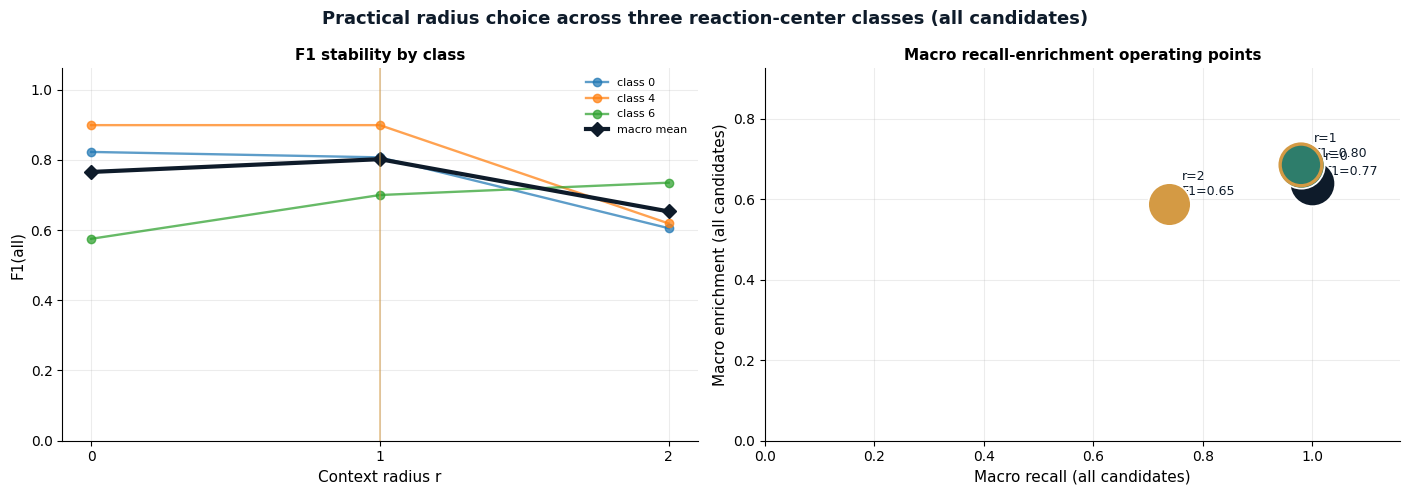

Best macro trade-off: r=1 with F1(all)=0.8018.


In [40]:
import matplotlib.pyplot as plt

_recall_check = f"Recall({_CHECK_LABEL})"
_enrich_check = f"Enrichment({_CHECK_LABEL})"
_f1_check = f"F1({_CHECK_LABEL})"
_palette = {0: "#0E1B2A", 1: "#2E7D6B", 2: "#D49A44"}

fig, (ax_line, ax_point) = plt.subplots(1, 2, figsize=(14.2, 5.0), facecolor="white")
fig.suptitle(
    "Practical radius choice across three reaction-center classes (all candidates)",
    fontsize=13,
    fontweight="bold",
    color="#0E1B2A",
)

for class_id, g in _multi_df.groupby("class"):
    g = g.sort_values("r")
    ax_line.plot(
        g["r"],
        g[_f1_check],
        marker="o",
        lw=1.7,
        alpha=0.72,
        label=f"class {class_id}",
    )
ax_line.plot(
    _macro_df["r"],
    _macro_df["f1_mean"],
    marker="D",
    color="#0E1B2A",
    lw=3.0,
    ms=7,
    label="macro mean",
)
ax_line.axvline(int(_best_macro["r"]), color="#D49A44", lw=1.4, alpha=0.5)
ax_line.set_xlabel("Context radius r", fontsize=11)
ax_line.set_ylabel(_f1_check, fontsize=11)
ax_line.set_title("F1 stability by class", fontsize=11, fontweight="bold")
ax_line.set_xticks(_RADIUS_CHECK)
ax_line.set_ylim(0, max(0.12, _multi_df[_f1_check].max() * 1.18))
ax_line.grid(alpha=0.24)
ax_line.legend(frameon=False, fontsize=8, loc="best")
ax_line.spines[["top", "right"]].set_visible(False)

for _, row in _macro_df.iterrows():
    size = 260 + 850 * row["f1_mean"] / max(_macro_df["f1_mean"].max(), 0.001)
    ax_point.scatter(
        row["recall_mean"],
        row["enrichment_mean"],
        s=size,
        color=_palette[int(row["r"])],
        edgecolor="white",
        linewidth=1.3,
        zorder=5,
    )
    ax_point.annotate(
        f"r={int(row['r'])}\nF1={row['f1_mean']:.2f}",
        (row["recall_mean"], row["enrichment_mean"]),
        textcoords="offset points",
        xytext=(9, 6),
        fontsize=9,
        color="#0E1B2A",
    )
ax_point.scatter(
    _best_macro["recall_mean"],
    _best_macro["enrichment_mean"],
    s=900,
    facecolors="none",
    edgecolors="#D49A44",
    linewidth=2.4,
    zorder=6,
)
ax_point.set_xlabel("Macro recall (all candidates)", fontsize=11)
ax_point.set_ylabel("Macro enrichment (all candidates)", fontsize=11)
ax_point.set_title(
    "Macro recall-enrichment operating points", fontsize=11, fontweight="bold"
)
ax_point.set_xlim(0, max(0.15, _macro_df["recall_mean"].max() * 1.16))
ax_point.set_ylim(0, max(0.05, _macro_df["enrichment_mean"].max() * 1.35))
ax_point.grid(alpha=0.24)
ax_point.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(
    f"Best macro trade-off: r={int(_best_macro['r'])} "
    f"with F1(all)={_best_macro['f1_mean']:.4f}."
)

**Practical guidelines**

| Situation | Action |
|---|---|
| r = 0 has high all-candidate recall but low enrichment | Add local context and test r = 1 |
| r = 1 improves all-candidate F1 across most classes | Use r = 1 as the first practical default |
| r = 2 improves only one class but hurts the macro mean | Keep r = 1 globally and override per class only when justified |
| Recall drops sharply from r = 1 to r = 2 | The larger template is becoming too specific |
| Runtime is too high | Cap the maximum radius or pre-filter candidate templates |

In practice, choose a radius from a validation set, report the all-candidate macro-average trade-off, and inspect per-class curves before treating the radius as a default.


<a id="4-discussion"></a>

## 4. Discussion

### Key takeaways

**Context radius controls generality.**
Small radii make broad templates. Larger radii add local chemical information and usually make templates more specific.

**Deduplication matters.**
Many training reactions can produce the same context graph at a given radius. Deduplicating those graphs keeps the template library compact.

**Recall@K and enrichment@K should be read together.**
Recall@K asks whether the correct reaction appears. Enrichment@K asks how focused the candidate list is. In this talktorial, `tradeoff_score` is the F1 score between them.

**Evaluate within a comparable class.**
The radius decision is easier to interpret when all test reactions share the same reaction-center family.

**The simple pipeline**

SMILES -> ITS -> reaction center -> r-hop context -> deduplicated templates -> `SynReactor` -> standardized recall@K, enrichment@K, and F1@K -> choose *r*.

This is the conceptual endpoint of the SynEdu series.


<a id="5-quiz"></a>

## 5. Quiz

1. If you increase radius *r* from 2 to 3 for one reaction family, do you always get more unique templates? Explain the role of deduplication.
2. At *r* = 0, why can two reactions with the same reaction center but different remote substituents collapse to the same template?
3. When two radii have similar recall but different enrichment, which radius is more useful for a focused search workflow and why?
4. Why should the radius trade-off be evaluated within comparable reaction-center families rather than across unrelated classes?


## 6. References

1. Phan, T.-L. *et al.* SynKit: A Graph-Based Python Framework for Rule-Based Reaction Modeling and Analysis. *Journal of Chemical Information and Modeling* (2025). https://doi.org/10.1021/acs.jcim.5c02123
2. Shervashidze, N.; Schweitzer, P.; van Leeuwen, E. J.; Mehlhorn, K.; Borgwardt, K. M. Weisfeiler-Lehman Graph Kernels. *Journal of Machine Learning Research* **12**, 2539-2561 (2011).
3. Ehrig, H.; Ehrig, K.; Prange, U.; Taentzer, G. *Fundamentals of Algebraic Graph Transformation*. Springer (2006). https://doi.org/10.1007/3-540-31188-2
4. Coley, C. W.; Green, W. H.; Jensen, K. F. RDChiral: An RDKit Wrapper for Handling Stereochemistry in Retrosynthetic Template Extraction and Application. *Journal of Chemical Information and Modeling* **59**, 2529-2537 (2019). https://doi.org/10.1021/acs.jcim.9b00286
5. RDKit documentation. https://www.rdkit.org/docs/
6. Daylight Theory Manual. *Reaction SMILES and SMARTS*.
7. Schneider, N.; Stiefl, N.; Landrum, G. A. What's What: The (Nearly) Definitive Guide to Reaction Role Assignment. *Journal of Chemical Information and Modeling* **56**, 2336-2346 (2016). https://doi.org/10.1021/acs.jcim.6b00564
